# Disease Prediction Model - Exploratory Data Analysis

## 1. Loading the data

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path

warnings.filterwarnings("ignore")

In [35]:
root = Path().resolve().parent

df_diabetes = pd.read_csv(root / "data" / "processed" / "diabetes_transformed.csv")
df_hypertension = pd.read_csv(root / "data" / "processed" / "hypertension_transformed.csv")
df_heart_disease = pd.read_csv(root / "data" / "processed" / "heart_disease_transformed.csv")

print("Diabetes shape:     ", df_diabetes.shape)
print("Hypertension shape: ", df_hypertension.shape)
print("Heart Disease shape:", df_heart_disease.shape)

Diabetes shape:      (10000, 8)
Hypertension shape:  (1985, 12)
Heart Disease shape: (10000, 27)


All three transformed datasets have been loaded and a `plots` directory is created to store all saved plotsand figures.

In [38]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
TITLE_SIZE = 14
LABEL_SIZE = 11
FIG_DPI    = 120

BLUE = "#5B8DB8"
ORANGE = "#E07B54"

plots_path = root / "plots"

## 2. Exploratory Data Analysis    

Now that the datasets are cleaned and transformed, we can perform EDA. The analysis follows the below pipeline for each dataset:

1. Inspecting the dataset
2. Understanding target distribution
3. Singular feature distributions 
4. Feature distributions against target variable
5. Categorical feature analysis
6. Correlation heatmap
7. Key insights

### 2.1 Diabetes Dataset

Inspecting the dataset

In [5]:
df_diabetes.describe().round(3)

,age,bmi,hba1c_level,blood_glucose_level,diabetes,metabolic_index,gender,smoking_history
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,0.000,-0.000,0.000,-0.000,0.087,-0.000,0.413,2.243
std,1.000,1.000,1.000,1.000,0.282,0.644,0.493,1.877
min,-1.852,-2.564,-1.883,-1.430,0.000,-1.694,0.000,0.000
25%,-0.787,-0.580,-0.672,-0.939,0.000,-0.420,0.000,0.000
50%,0.057,0.004,0.260,0.043,0.000,-0.045,0.000,3.000
75%,0.812,0.391,0.632,0.509,0.000,0.345,1.000,4.000
max,1.700,4.830,3.241,3.971,1.000,3.044,2.000,5.000


**Understanding the target variable distribution**

Since we sampled the diabetes dataset to 10,000 entries and made it so that it has a perfectly balanced distribution, we know how the split will look like. Nevertheless, we have shown it just for uniformity.

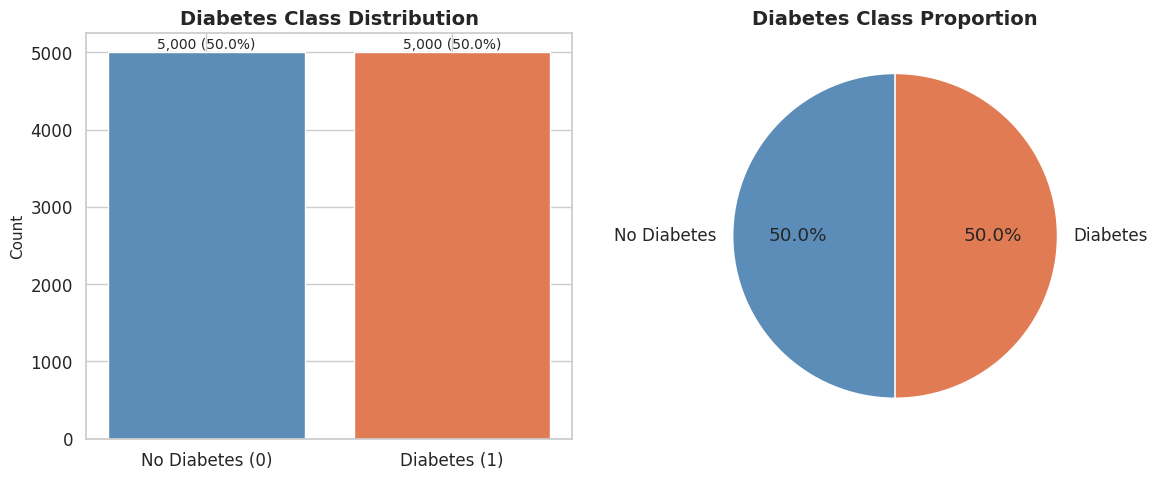

Class distribution:
 diabetes
1    5000
0    5000


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df_diabetes["diabetes"].value_counts()

axes[0].bar(["No Diabetes (0)", "Diabetes (1)"], target_counts.values,
            color=[BLUE, ORANGE])
axes[0].set_title("Diabetes Class Distribution", fontsize=TITLE_SIZE, fontweight="bold")
axes[0].set_ylabel("Count", fontsize=LABEL_SIZE)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f"{v:,} ({v/len(df_diabetes)*100:.1f}%)",
                 ha="center", fontsize=10)

axes[1].pie(target_counts.values,
            labels=["No Diabetes", "Diabetes"],
            autopct="%1.1f%%",
            colors=[BLUE, ORANGE],
            startangle=90)
axes[1].set_title("Diabetes Class Proportion", fontsize=TITLE_SIZE, fontweight="bold")

plt.tight_layout()
plt.savefig(plots_path / "diabetes_class_distribution.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("Class distribution:\n", target_counts.to_string())

Feature distributions

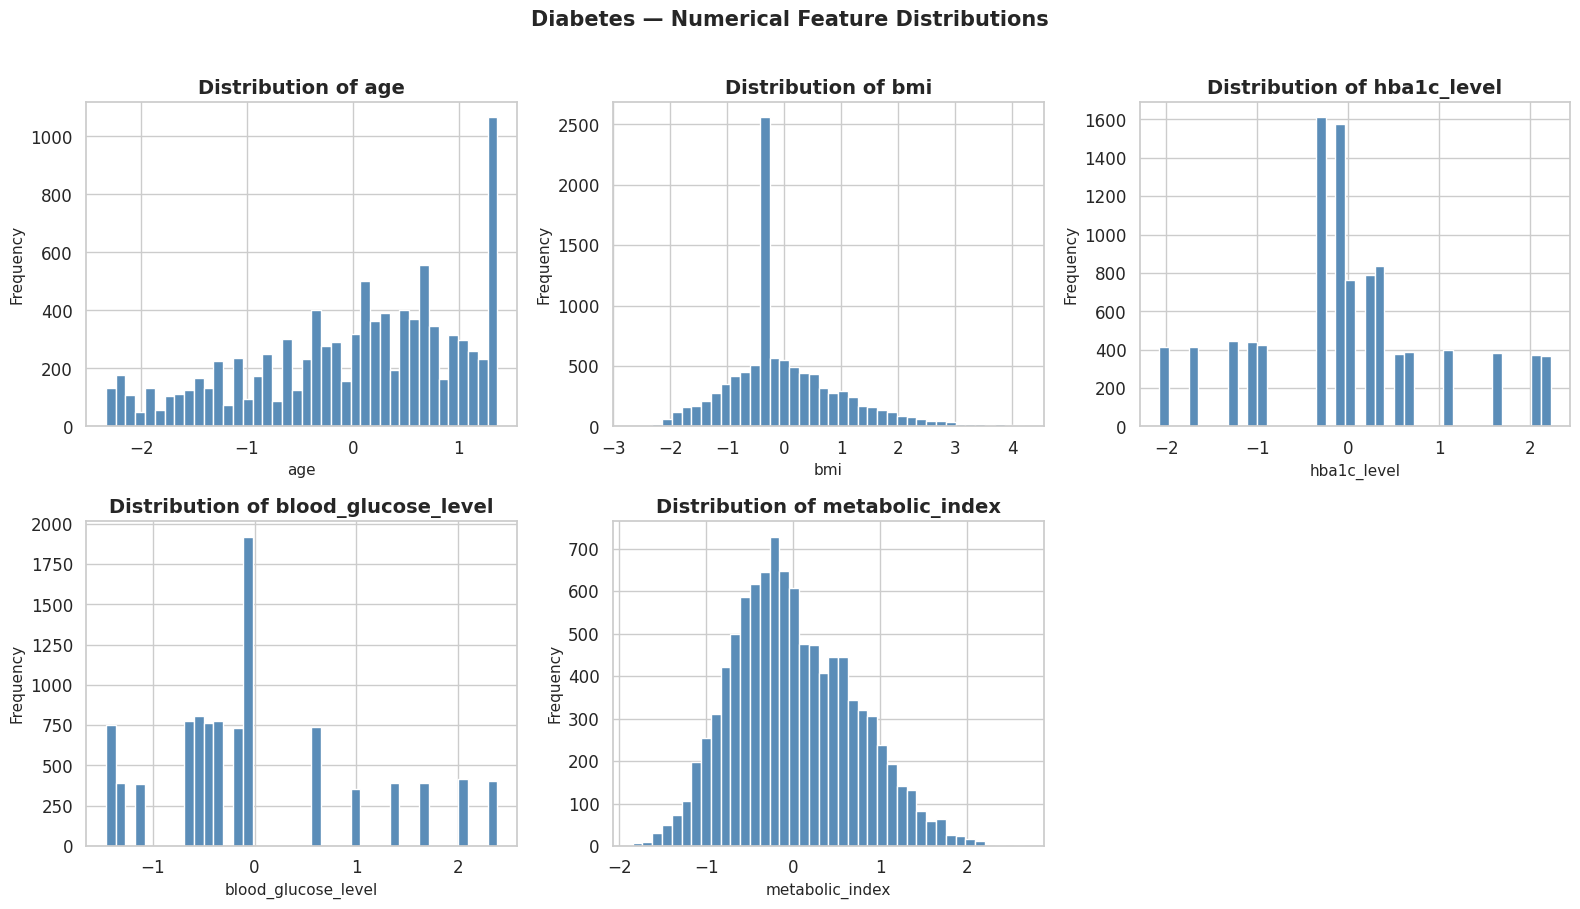

In [45]:
numerical_features = ["age", "bmi", "hba1c_level", "blood_glucose_level", "metabolic_index"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df_diabetes[col], bins=40, color=BLUE)
    axes[i].set_title(f"Distribution of {col}", fontsize=TITLE_SIZE, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=LABEL_SIZE)
    axes[i].set_ylabel("Frequency", fontsize=LABEL_SIZE)

axes[-1].set_visible(False)
plt.suptitle("Diabetes — Numerical Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(plots_dir / "diabetes_feature_distributions.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insight:** Age is fairly uniformly distributed with a concentration in older patients (60+), which is understandable from a medical standpoint as diabetes risk increases with age. Since we sampled our target variables in a balnced way, the amount of low and high risk individuals are similiar and hence other features are not really skewed in any direction.